# **Project Name**    -
**Enterprise E-Commerce Analytics Platform**

# **Project Summary -**

**Project Summary**

This project presents a comprehensive Exploratory Data Analysis (EDA) of the Brazilian E-Commerce Public Dataset (Olist) with the objective of uncovering meaningful business insights related to customer behavior, sales performance, logistics efficiency, payment preferences, and product performance.

The analysis began with cleaning and preprocessing nine interconnected datasets, including customers, orders, products, payments, reviews, sellers, geolocation, product categories, and order items. Data quality issues such as missing values, incorrect data types, and inconsistencies were carefully handled while preserving the integrity of the original business process. The datasets were then merged into a unified analytical dataset, followed by feature engineering to derive meaningful business metrics such as delivery time, fulfillment time, delivery delay, product volume, total order value, repeat customer status, and several time-based features.

Using 22 business-oriented visualizations, the project explores sales trends, customer distribution, seller performance, product categories, payment behavior, logistics performance, customer satisfaction, and correlations among key business variables. The analysis identifies high-performing states and product categories, highlights customer payment preferences, evaluates delivery efficiency, and demonstrates the relationship between operational performance and customer reviews.

Overall, the project transforms raw transactional data into actionable business insights that can support decision-making in sales strategy, inventory management, logistics optimization, customer retention, payment optimization, and marketplace growth. The notebook follows a structured end-to-end analytics workflow and demonstrates practical skills in data cleaning, feature engineering, exploratory data analysis, data visualization, and business storytelling using Python, Pandas, Matplotlib, and Seaborn.

### **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

### **Dataset Loading**

In [2]:
data_customers=pd.read_csv('C:\datsets+dashboards/olist_customers_dataset.csv')
data_locations=pd.read_csv('C:\datsets+dashboards/olist_geolocation_dataset.csv')
data_items=pd.read_csv('C:\datsets+dashboards/olist_order_items_dataset.csv')
data_payments=pd.read_csv('C:\datsets+dashboards/olist_order_payments_dataset.csv')
data_reviews=pd.read_csv('C:\datsets+dashboards/olist_order_reviews_dataset.csv')
data_orders=pd.read_csv('C:\datsets+dashboards/olist_orders_dataset.csv')
data_products=pd.read_csv('C:\datsets+dashboards/olist_products_dataset.csv')
data_sellers=pd.read_csv('C:\datsets+dashboards/olist_sellers_dataset.csv')
data_translations=pd.read_csv('C:\datsets+dashboards/product_category_name_translation.csv')

### **Dataset First View**

In [3]:
data_customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
data_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [5]:
data_locations.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [6]:
data_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [7]:
data_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [8]:
data_products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [9]:
data_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [10]:
data_sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [11]:
data_translations.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


### **Dataset Rows & Columns count**

In [12]:
tables = {
    "Customers": data_customers,
    "Locations": data_locations,
    "Items": data_items,
    "Orders": data_orders,
    "Payments": data_payments,
    "Products": data_products,
    "Reviews": data_reviews,
    "Sellers": data_sellers,
    "Translations": data_translations
}

for name, df in tables.items():
    print(f"{name}: {df.shape}")

Customers: (99441, 5)
Locations: (1000163, 5)
Items: (112650, 7)
Orders: (99441, 8)
Payments: (103886, 5)
Products: (32951, 9)
Reviews: (99224, 7)
Sellers: (3095, 4)
Translations: (71, 2)


### **Dataset Information**

In [13]:
for name, df in tables.items():
    print(f"{name}: {df.columns}")

Customers: Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')
Locations: Index(['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng',
       'geolocation_city', 'geolocation_state'],
      dtype='object')
Items: Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')
Orders: Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')
Payments: Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')
Products: Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       

In [14]:
for name, df in tables.items():
    print(f"{name}: {df.select_dtypes(include='object')}")

Customers:                             customer_id                customer_unique_id  \
0      06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1      18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2      4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3      b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4      4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   
...                                 ...                               ...   
99436  17ddf5dd5d51696bb3d7c6291687be6f  1a29b476fee25c95fbafc67c5ac95cf8   
99437  e7b71a9017aa05c9a7fd292d714858e8  d52a67c98be1cf6a5c84435bd38d095d   
99438  5e28dfe12db7fb50a4b2f691faecea5e  e9f50caf99f032f0bf3c55141f019d99   
99439  56b18e2166679b8a959d72dd06da27f9  73c2643a0a458b49f58cea58833b192e   
99440  274fa6071e5e17fe303b9748641082c8  84732c5050c01db9b23e19ba39899398   

               customer_city customer_state  
0                 

In [15]:
for name, df in tables.items():
    print(f"{name}: {df.select_dtypes(include={'int64','float64'})}")

Customers:        customer_zip_code_prefix
0                         14409
1                          9790
2                          1151
3                          8775
4                         13056
...                         ...
99436                      3937
99437                      6764
99438                     60115
99439                     92120
99440                      6703

[99441 rows x 1 columns]
Locations:          geolocation_zip_code_prefix  geolocation_lat  geolocation_lng
0                               1037       -23.545621       -46.639292
1                               1046       -23.546081       -46.644820
2                               1046       -23.546129       -46.642951
3                               1041       -23.544392       -46.639499
4                               1035       -23.541578       -46.641607
...                              ...              ...              ...
1000158                        99950       -28.068639       -52.010705


### **Missing Values/Null Values**

In [16]:
for name, df in tables.items():
    print(f"{name}: {df.isnull().sum()}")

Customers: customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
Locations: geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64
Items: order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64
Orders: order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
Payments: order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
pay

In [17]:
for name, df in tables.items():
    print(f"{name}: {df.nunique().sum()}")

Customers: 214677
Locations: 1462026
Items: 241018
Orders: 565639
Payments: 128575
Products: 38569
Reviews: 336658
Sellers: 5975
Translations: 142


#### **Duplicate Values**

In [18]:
for name, df in tables.items():
    print(f"{name}: {df.duplicated().sum()}")

Customers: 0
Locations: 261831
Items: 0
Orders: 0
Payments: 0
Products: 0
Reviews: 0
Sellers: 0
Translations: 0


In [19]:
for name, df in tables.items():
    print(f"{name}: {df.info()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
Customers: None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             10

In [20]:
for name, df in tables.items():
    print(f"{name}: {df.describe()}")

Customers:        customer_zip_code_prefix
count              99441.000000
mean               35137.474583
std                29797.938996
min                 1003.000000
25%                11347.000000
50%                24416.000000
75%                58900.000000
max                99990.000000
Locations:        geolocation_zip_code_prefix  geolocation_lat  geolocation_lng
count                 1.000163e+06     1.000163e+06     1.000163e+06
mean                  3.657417e+04    -2.117615e+01    -4.639054e+01
std                   3.054934e+04     5.715866e+00     4.269748e+00
min                   1.001000e+03    -3.660537e+01    -1.014668e+02
25%                   1.107500e+04    -2.360355e+01    -4.857317e+01
50%                   2.653000e+04    -2.291938e+01    -4.663788e+01
75%                   6.350400e+04    -1.997962e+01    -4.376771e+01
max                   9.999000e+04     4.506593e+01     1.211054e+02
Items:        order_item_id          price  freight_value
count  1126

### ***Data Wrangling***

In [21]:
data_items['shipping_limit_date'] = pd.to_datetime(data_items['shipping_limit_date'])
data_orders['order_purchase_timestamp'] = pd.to_datetime(data_orders['order_purchase_timestamp'])
data_orders['order_approved_at'] = pd.to_datetime(data_orders['order_approved_at'])
data_orders['order_delivered_carrier_date'] = pd.to_datetime(data_orders['order_delivered_carrier_date'])
data_orders['order_delivered_customer_date'] = pd.to_datetime(data_orders['order_delivered_customer_date'])
data_orders['order_estimated_delivery_date'] = pd.to_datetime(data_orders['order_estimated_delivery_date'])
data_reviews['review_creation_date'] = pd.to_datetime(data_reviews['review_creation_date'])
data_reviews['review_answer_timestamp'] = pd.to_datetime(data_reviews['review_answer_timestamp'])

In [22]:
data_orders[data_orders['order_delivered_customer_date'].isnull()]['order_status'].value_counts()

shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: order_status, dtype: int64

In [23]:
data_orders[data_orders['order_approved_at'].isnull()]['order_status'].value_counts()

canceled     141
delivered     14
created        5
Name: order_status, dtype: int64

In [24]:
data_orders[data_orders['order_delivered_carrier_date'].isnull()]['order_status'].value_counts()

unavailable    609
canceled       550
invoiced       314
processing     301
created          5
approved         2
delivered        2
Name: order_status, dtype: int64

### **Data Cleaning**


### Customer table
No cleaning was required for this table as it contained no missing values or duplicate records, and all columns were already in the appropriate data format.

In [25]:
#location table
data_locations.duplicated().sum()

261831

In [26]:
data_locations.duplicated(subset=['geolocation_zip_code_prefix']).sum()

981148

In [27]:
data_locations = data_locations.drop_duplicates()

### Locations Table
The geolocation dataset contains many repeated city, state, and ZIP code values because multiple geographic coordinates can belong to the same ZIP code prefix. These are valid records and were retained. Only completely identical rows were removed as duplicate records to improve data quality while preserving useful geographic information.

In [28]:
#items table
data_items['shipping_limit_date'] = pd.to_datetime(data_items['shipping_limit_date'])

### Items Table

The **`shipping_limit_date`** column was converted from **object** to **datetime** format to enable accurate date-based analysis and calculations. No missing values or duplicate records were found in the dataset, indicating that the table was already complete and consistent. Therefore, apart from the data type conversion, no additional cleaning was required.


In [29]:
#orders table
data_orders['order_purchase_timestamp'] = pd.to_datetime(data_orders['order_purchase_timestamp'])
data_orders['order_approved_at'] = pd.to_datetime(data_orders['order_approved_at'])
data_orders['order_delivered_carrier_date'] = pd.to_datetime(data_orders['order_delivered_carrier_date'])
data_orders['order_delivered_customer_date'] = pd.to_datetime(data_orders['order_delivered_customer_date'])
data_orders['order_estimated_delivery_date'] = pd.to_datetime(data_orders['order_estimated_delivery_date'])

### Orders Table

The relevant timestamp columns were converted from **object** to **datetime** format to enable accurate time-based analysis, including order processing, shipping, and delivery duration calculations. No duplicate records were found in the dataset. Missing values were identified in the **`order_approved_at`**, **`order_delivered_carrier_date`**, and **`order_delivered_customer_date`** columns. Instead of directly imputing these values, the missing timestamps were analyzed in the context of the order lifecycle. Most missing timestamps corresponded to orders with statuses such as **canceled**, **created**, **processing**, **invoiced**, **unavailable**, or **shipped**, indicating that the respective event (approval, carrier pickup, or customer delivery) had not occurred. A small number of records showed inconsistencies, such as **delivered** orders with missing approval or carrier timestamps, which were identified as potential data quality issues. To preserve the integrity and authenticity of the dataset, all missing timestamp values were retained as **`NaT`** instead of being imputed using statistical methods such as the mode or median, ensuring that subsequent analyses accurately reflect the actual business process.


### Payments Table

The Payments table was found to be clean and required no data preprocessing. All columns were already in the appropriate data types, with no missing values or duplicate records detected. Therefore, no cleaning operations were performed, and the dataset was retained in its original form for further analysis.


In [30]:
data_products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [31]:
data_products['product_category_name'] = data_products['product_category_name'].fillna('Unknown')
cols = [
    'product_name_lenght',
    'product_description_lenght',
    'product_photos_qty',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

for col in cols:
    data_products[col].fillna(data_products[col].median(), inplace=True)

###Products Table
The Products table contained no duplicate records but had missing values primarily in the product metadata fields, including product_category_name, product_name_lenght, product_description_lenght, and product_photos_qty. These missing values occurred together for the same set of products, indicating incomplete product information rather than random data loss. To preserve the dataset while minimizing bias, missing product categories were labeled as "Unknown", whereas the numerical attributes were imputed using the median, which is robust to outliers. Additionally, the small number of missing values in the physical dimension columns (product_weight_g, product_length_cm, product_height_cm, and product_width_cm) were also replaced with their respective median values.

In [32]:
data_reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [33]:
data_reviews['review_comment_title'] = data_reviews['review_comment_title'].fillna('No Title')
data_reviews['review_comment_message'] = data_reviews['review_comment_message'].fillna('No Message')

In [34]:
data_reviews['review_creation_date'] = pd.to_datetime(data_reviews['review_creation_date'])
data_reviews['review_answer_timestamp'] = pd.to_datetime(data_reviews['review_answer_timestamp'])

### Reviews Table

The Reviews table contained no duplicate records. Missing values were identified in the **`review_comment_title`** and **`review_comment_message`** columns. Since these fields are optional and many customers submit only a rating without providing written feedback, the missing values were not treated as data quality issues. Instead, they were replaced with **"No Title"** and **"No Comment"**, respectively, to preserve the meaning of the data while facilitating text-based analysis. Additionally, the **`review_creation_date`** and **`review_answer_timestamp`** columns were converted from **object** to **datetime** format to enable accurate time-based analysis and ensure consistency across the dataset.


### Sellers Table

The Sellers table was found to be clean and required no preprocessing. No missing values or duplicate records were detected, and all columns were already stored in the appropriate data types. Therefore, no data cleaning operations were required, and the table was retained in its original form for further analysis.


### Product Category Translation Table

The Product Category Translation table was found to be clean and required no preprocessing. No missing values or duplicate records were identified, and all columns were already in the appropriate data types. Therefore, no data cleaning operations were necessary, and the table was retained in its original form for further analysis.


## **Feature Engineering**

#### **Merging all the tables**

In [35]:
merged_df=data_orders.copy()

In [36]:
merged_df = merged_df.merge(data_items, on='order_id', how='left')

In [37]:
merged_df = merged_df.merge(data_payments, on='order_id', how='left')

In [38]:
merged_df = merged_df.merge(data_reviews, on='order_id', how='left')

In [39]:
merged_df = merged_df.merge(data_customers, on='customer_id', how='left')

In [40]:
merged_df = merged_df.merge(data_products, on='product_id', how='left')

In [41]:
merged_df = merged_df.merge(data_sellers, on='seller_id', how='left')

In [42]:
merged_df = merged_df.merge(data_translations, on='product_category_name', how='left')

In [43]:
merged_df.shape

(119143, 40)

### **Time-based Features**

In [44]:
merged_df['order_processing_time']=(merged_df['order_approved_at']-merged_df['order_purchase_timestamp']).dt.days

In [45]:
merged_df['shipping_time']=(merged_df['order_delivered_carrier_date']-merged_df['order_approved_at']).dt.days

In [46]:
merged_df['delivery_time']=(merged_df['order_delivered_customer_date']-merged_df['order_delivered_carrier_date']).dt.days

In [47]:
merged_df['total_fulfillment_time']=(merged_df['order_delivered_customer_date']-merged_df['order_purchase_timestamp']).dt.days

In [48]:
merged_df['delivery_delay_days']=(merged_df['order_delivered_customer_date']-merged_df['order_estimated_delivery_date']).dt.days

In [49]:
merged_df['delayed'] = np.where(merged_df['delivery_delay_days'] > 0,'Yes','No')

### **Date Features**

In [50]:
merged_df['purchase_month']=merged_df['order_purchase_timestamp'].dt.month
merged_df['purchase_year']=merged_df['order_purchase_timestamp'].dt.year
merged_df['purchase_weekday']=merged_df['order_purchase_timestamp'].dt.weekday
merged_df['weekend'] = merged_df['purchase_weekday'].apply(lambda x: 'Yes' if x>5 else 'No')

### **Product Features**

In [51]:
merged_df['product_volume']=merged_df['product_length_cm']*merged_df['product_height_cm']*merged_df['product_width_cm']

### **Customer Features**

In [52]:
customer_orders = (merged_df.groupby('customer_unique_id')['order_id'].nunique().reset_index())
customer_orders.columns = ['customer_unique_id','customer_lifetime_orders']
merged_df = merged_df.merge(customer_orders,on='customer_unique_id',how='left')

In [53]:
merged_df['repeat_customer'] = np.where(merged_df['customer_lifetime_orders'] > 1,'Yes','No')

### **Payment Features**

In [54]:
merged_df['installment_flag']=np.where(merged_df['payment_installments']>1,'Multi Installments','Single Payment')

### **Business Flags**

In [55]:
order_payment = (data_payments.groupby('order_id')['payment_value'].sum().reset_index())
order_payment.rename(columns={'payment_value': 'total_order_value'}, inplace=True)
merged_df = merged_df.merge(order_payment,on='order_id',how='left')

In [56]:
threshold = merged_df['total_order_value'].quantile(0.75)
merged_df['high_value_order'] = np.where(merged_df['total_order_value'] >= threshold,'Yes','No')

## **Data Visualizations**

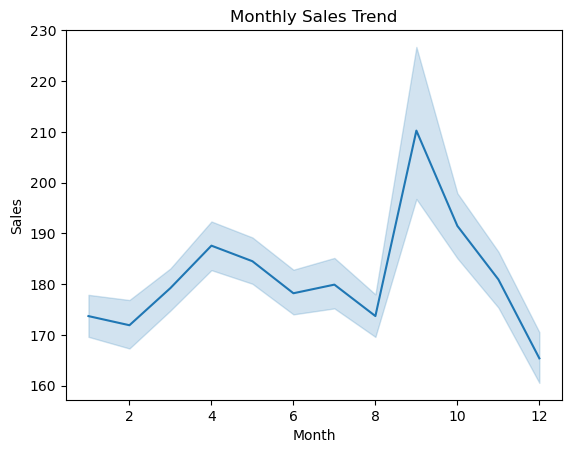

In [57]:
#chart 1
sns.lineplot(x=merged_df['purchase_month'],y=merged_df['total_order_value'])
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

Business Question:
How do sales vary across different months?

Visualization:
Line chart showing Monthly Sales Trend.

Key Insight:
Sales exhibit noticeable monthly fluctuations throughout the year, with September recording the highest sales among all months. This peak suggests a period of increased customer demand or promotional activity, while sales decline during the final quarter, particularly in December. Understanding these seasonal patterns can help optimize inventory planning, marketing campaigns, and resource allocation during high-demand periods.

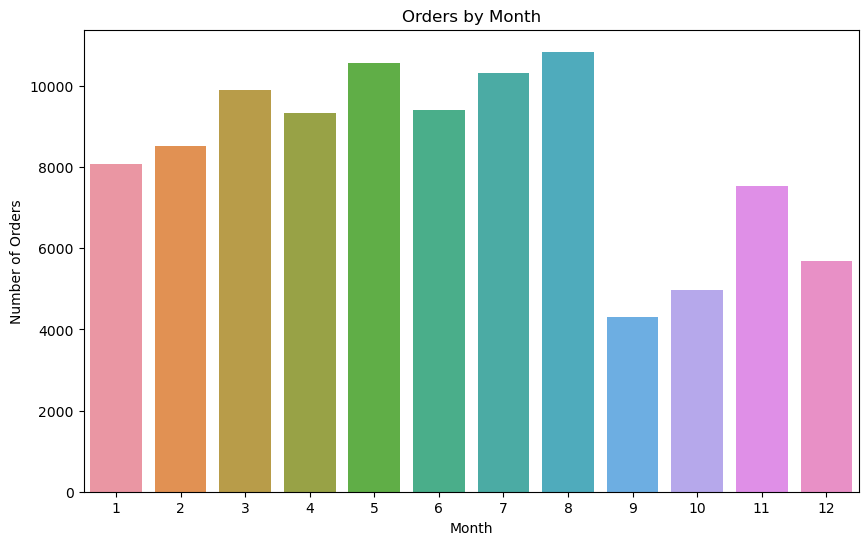

In [58]:
#chart 2
monthly_orders = (merged_df.groupby('purchase_month')['order_id'].nunique().sort_index())
plt.figure(figsize=(10,6))
sns.barplot(x=monthly_orders.index,y=monthly_orders.values)
plt.title('Orders by Month')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.show()

Business Question:
How does the number of customer orders vary across different months?

Visualization:
Bar Chart showing the Number of Orders by Month.

Key Insight:
Order volume varies throughout the year, with August recording the highest number of orders, followed closely by May and July. In contrast, November and December show comparatively lower order volumes. These seasonal variations can help businesses optimize inventory management, staffing, and marketing strategies during periods of high customer demand..

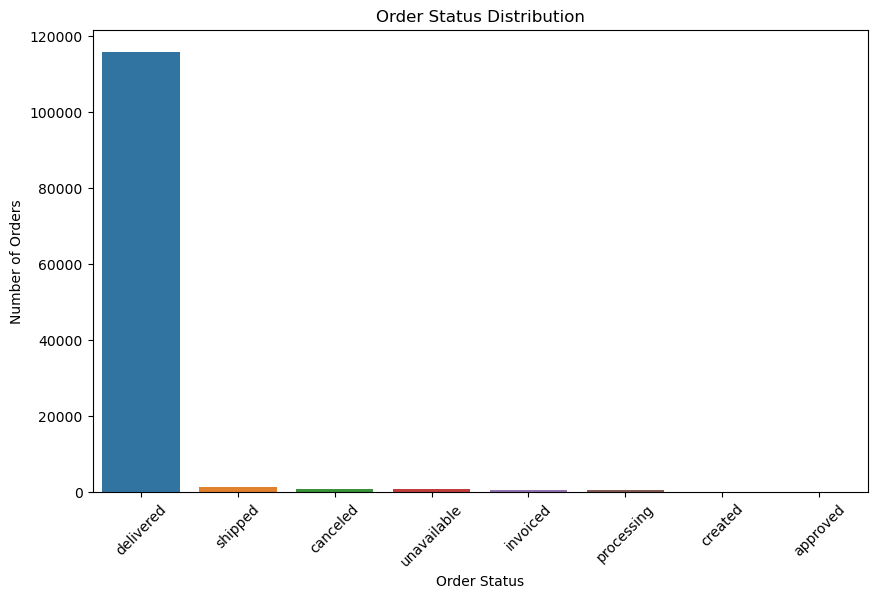

In [59]:
#chart 3
plt.figure(figsize=(10,6))
sns.countplot(data=merged_df,x='order_status',order=merged_df['order_status'].value_counts().index)
plt.title('Order Status Distribution')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()

Business Question:
What is the distribution of orders across different order statuses?

Visualization:
Bar Chart showing the distribution of orders by order status.

Key Insight:
Delivered orders dominate the dataset, demonstrating a strong order fulfillment rate. The comparatively low number of canceled, unavailable, and processing orders suggests that the e-commerce platform maintains an effective order management process. However, monitoring the small percentage of unsuccessful or pending orders can help identify opportunities to improve inventory availability, logistics, and customer experience.

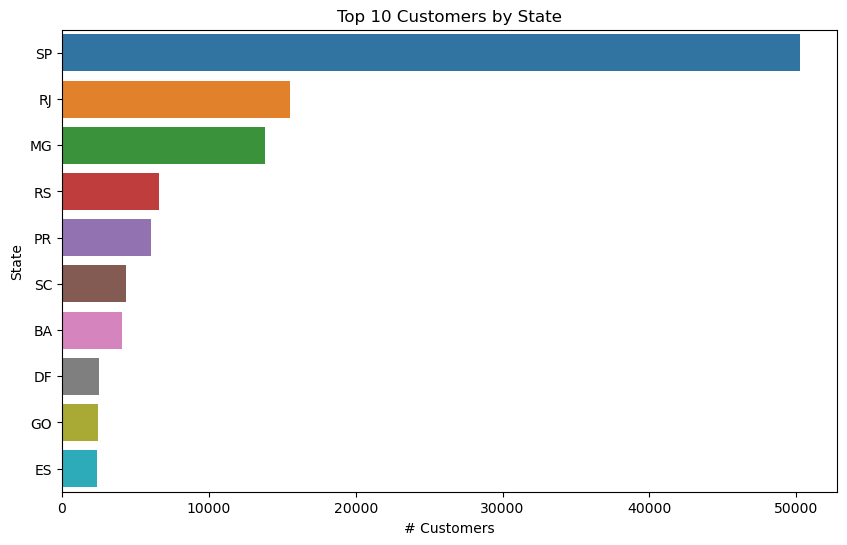

In [60]:
#Chart 4
top10=merged_df['customer_state'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(y=top10.index,x=top10.values)
plt.title('Top 10 Customers by State')
plt.ylabel('State')
plt.xlabel('# Customers')
plt.show()

Business Question:
Which states have the highest concentration of customers?

Visualization:
Bar Chart showing the top 10 states by customer count.

Key Insight:
São Paulo (SP) has the largest customer base by a significant margin, followed by Rio de Janeiro (RJ) and Minas Gerais (MG). This indicates that these states represent the platform's primary markets and contribute a substantial share of the customer base. Businesses can prioritize marketing campaigns, inventory planning, and customer engagement strategies in these high-demand regions.

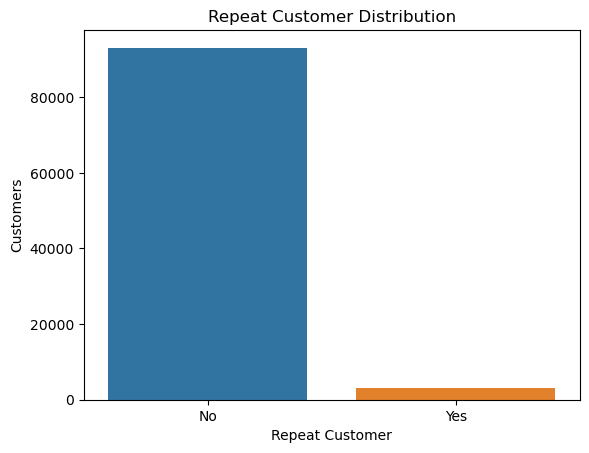

In [61]:
#chart 5
sns.barplot(x=merged_df.groupby('repeat_customer')['customer_unique_id'].nunique().index,y=merged_df.groupby('repeat_customer')['customer_unique_id'].nunique().values)
plt.title('Repeat Customer Distribution')
plt.xlabel('Repeat Customer')
plt.ylabel('Customers')
plt.show()

Business Question:
What proportion of customers are repeat customers?

Visualization:
Bar Chart showing the distribution of repeat and one-time customers.

Key Insight:
The majority of customers are one-time buyers, while a smaller proportion consists of repeat customers. This indicates an opportunity for the business to strengthen customer retention through loyalty programs, personalized recommendations, and improved post-purchase engagement.

Text(0, 0.5, 'Products')

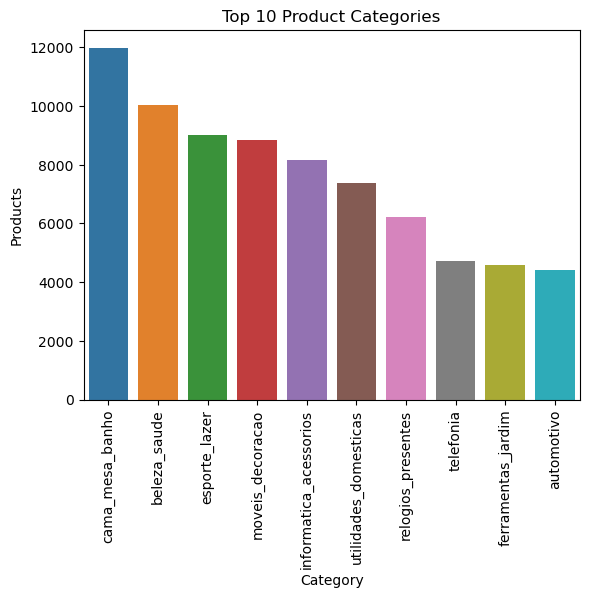

In [62]:
#chart 6
sns.barplot(x=merged_df['product_category_name'].value_counts().head(10).index,y=merged_df['product_category_name'].value_counts().head(10).values)
plt.title('Top 10 Product Categories')
plt.xlabel('Category')
plt.xticks(rotation=90)
plt.ylabel('Products')

Business Question:
Which product categories receive the highest number of orders?

Visualization:
Bar Chart showing the top 10 product categories by number of products sold.

Key Insight:
The Bed Bath Table (cama_mesa_banho) category has the highest number of products sold, followed by Health & Beauty (beleza_saude) and Sports & Leisure (esporte_lazer). These categories represent the platform's most popular product segments, indicating consistently high customer demand and making them key contributors to overall sales volume.

Text(0, 0.5, 'Sales')

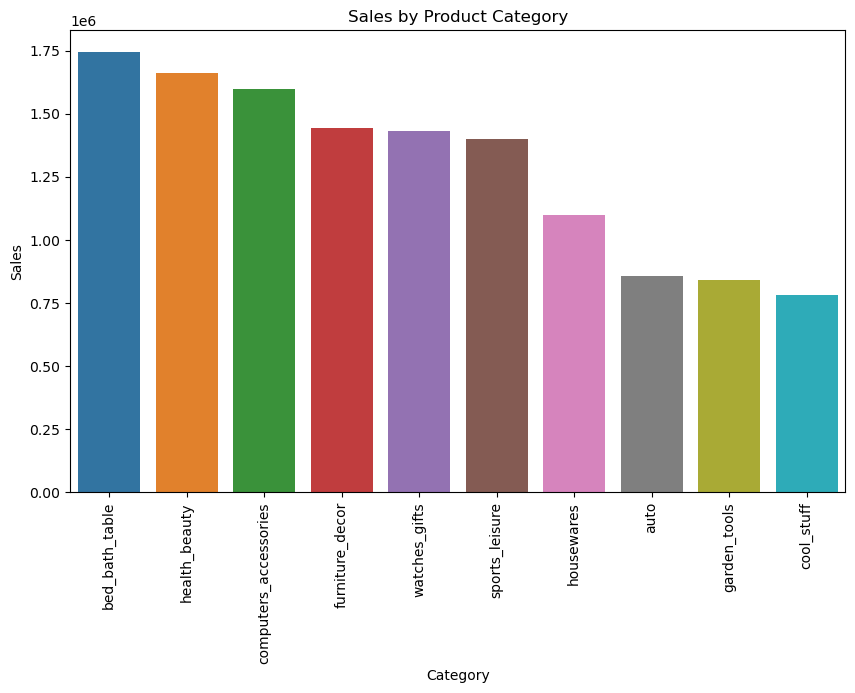

In [63]:
#chart 7
top=merged_df.groupby('product_category_name_english')['payment_value'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top.index,y=top.values)
plt.title('Sales by Product Category')
plt.xticks(rotation=90)
plt.xlabel('Category')
plt.ylabel('Sales')

Business Question:
Which product categories generate the highest revenue?

Visualization:
Bar Chart showing total revenue generated by the top 10 product categories.

Key Insight:
The Bed Bath Table (cama_mesa_banho) and Health & Beauty (beleza_saude) categories generated the highest revenue among all product categories. This indicates that these categories make a significant contribution to overall sales and should be prioritized for inventory management, supplier partnerships, and promotional campaigns.

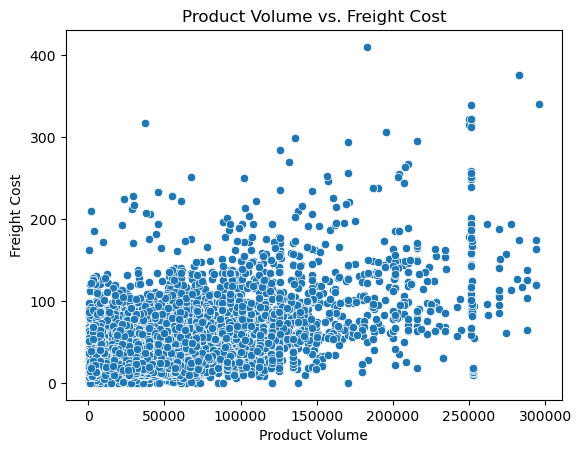

In [64]:
#chart 8
sns.scatterplot(x=merged_df['product_volume'],y=merged_df['freight_value'])
plt.title('Product Volume vs. Freight Cost')
plt.xlabel('Product Volume')
plt.ylabel('Freight Cost')
plt.show()

Business Question:
How does product volume influence freight cost?

Visualization:
Scatter Plot showing the relationship between product volume and freight cost.

Key Insight:
The scatter plot shows a positive relationship between product volume and freight cost. In general, larger products tend to incur higher shipping costs, although there is noticeable variation due to other factors such as product weight, shipping distance, and seller location. This suggests that product size is an important factor influencing logistics costs.

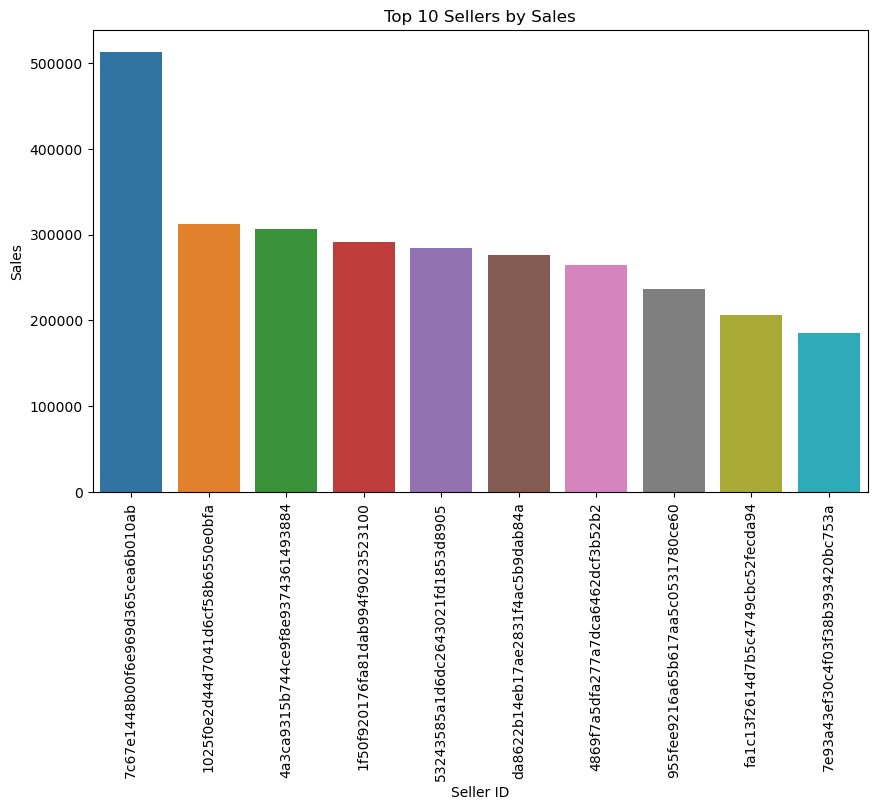

In [65]:
#chart 9
top=merged_df.groupby('seller_id')['payment_value'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top.index,y=top.values)
plt.title('Top 10 Sellers by Sales')
plt.xticks(rotation=90)
plt.xlabel('Seller ID')
plt.ylabel('Sales')
plt.show()

Business Question:
Which seller generates the highest revenue?

Visualization:
Bar Chart showing the top 10 sellers by total sales revenue.

Key Insight:
Seller 7c67e1448b00f6e969d365cea6b010ab generated the highest sales revenue among all sellers, followed by several other high-performing sellers. This indicates that a small number of sellers contribute a significant share of the platform's total revenue, highlighting the importance of supporting and retaining these key sellers.

Text(0, 0.5, 'Sellers')

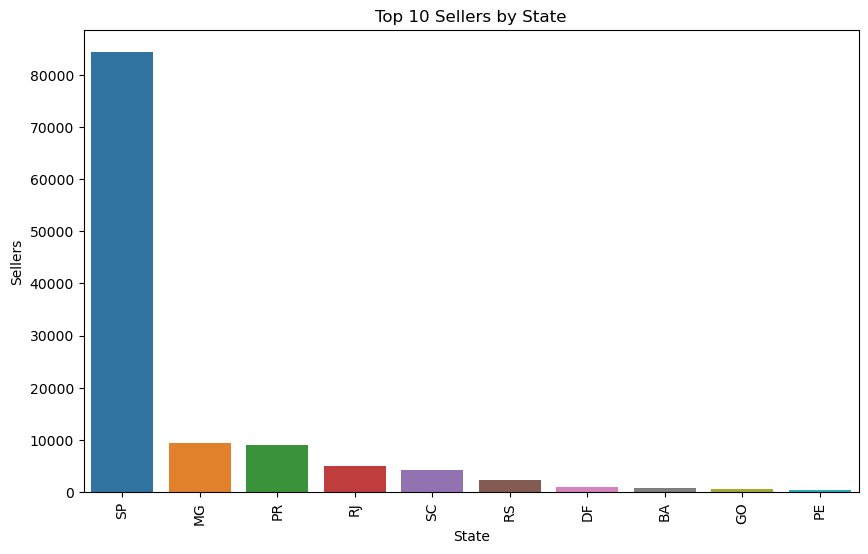

In [66]:
#chart 10
top=merged_df['seller_state'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top.index,y=top.values)
plt.title('Top 10 Sellers by State')
plt.xlabel('State')
plt.xticks(rotation=90)
plt.ylabel('Sellers')

Business Question:
Which states have the highest concentration of sellers on the platform?

Visualization:
Bar Chart showing the top 10 states by seller count.

Key Insight:
São Paulo (SP) has the highest concentration of sellers by a significant margin, followed by Minas Gerais (MG) and Paraná (PR). This indicates that seller operations are heavily concentrated in a few states, suggesting these regions serve as major supply hubs for the marketplace. Businesses can leverage this information to optimize logistics, warehouse planning, and seller acquisition strategies.

Text(0.5, 0, 'Number of Transactions')

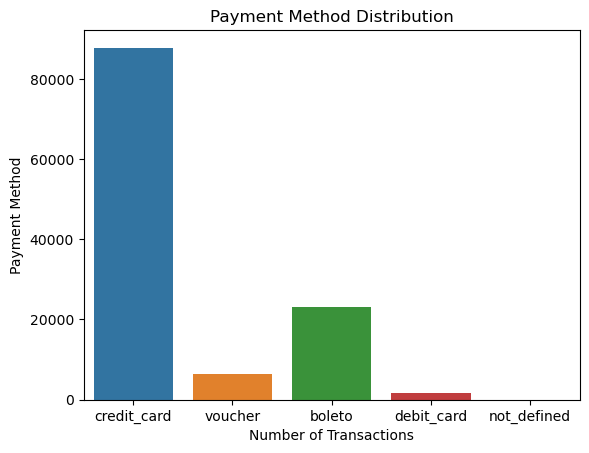

In [72]:
#chart 11
sns.countplot(data=merged_df,x='payment_type')
plt.title('Payment Method Distribution')
plt.ylabel('Payment Method')
plt.xlabel('Number of Transactions')

Business Question:
Which payment method is most frequently used by customers?

Visualization:
Count Plot showing the distribution of payment methods.

Key Insight:
Credit cards are the most preferred payment method among customers, accounting for a significantly higher number of transactions than boleto, vouchers, or debit cards. This indicates a strong customer preference for card-based payments, which can help businesses optimize payment processing and design targeted promotional offers.

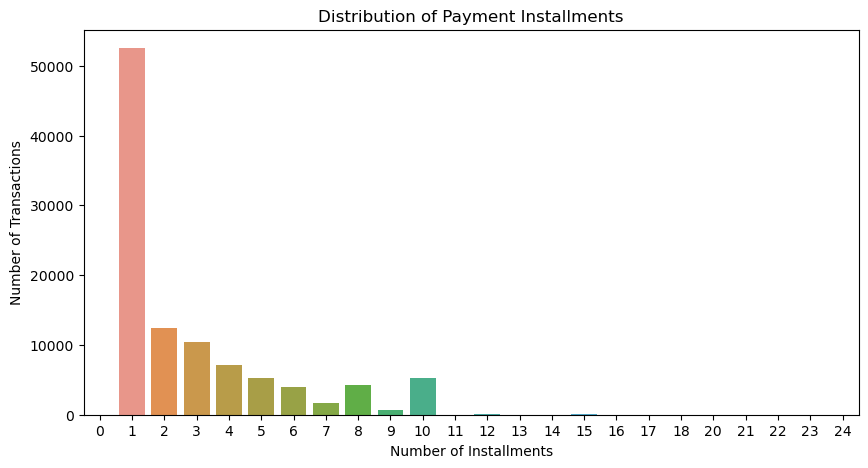

In [73]:
#chart 12
plt.figure(figsize=(10,5))
sns.countplot(data=data_payments,x='payment_installments')
plt.title('Distribution of Payment Installments')
plt.xlabel('Number of Installments')
plt.ylabel('Number of Transactions')
plt.show()

Business Question:
How do customers prefer to pay in terms of installment count?

Visualization:
Count Plot showing the distribution of payment installments.

Key Insight:
Most customers prefer to pay for their orders in a single installment, while the number of customers choosing multiple installments gradually decreases as the installment count increases. This indicates a general preference for completing payments immediately rather than spreading them over several installments.A noticeable increase is observed at 10 installments compared to nearby installment counts, suggesting that this may be a commonly offered financing option or a preferred repayment plan for higher-value purchases.

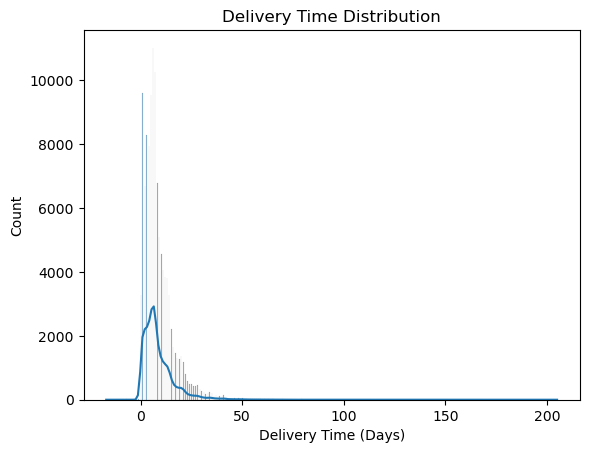

In [74]:
#chart 13
sns.histplot(merged_df['delivery_time'],kde=True)
plt.title('Delivery Time Distribution')
plt.xlabel('Delivery Time (Days)')
plt.show()

Business Question:
What is the distribution of delivery time across all completed orders?

Visualization:
Histogram with KDE showing the distribution of delivery time for completed orders.

Key Insight:
Most orders are delivered within 20 days, with the highest concentration of deliveries occurring during this period. The distribution is positively skewed, indicating that while the majority of orders are delivered relatively quickly, a small number of orders experience significantly longer delivery times. Identifying these delayed deliveries can help improve logistics efficiency and enhance the overall customer experience.

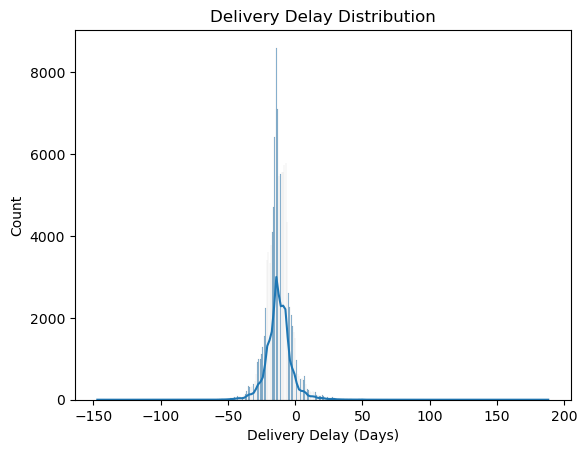

In [75]:
#chart 14
sns.histplot(merged_df['delivery_delay_days'],kde=True)
plt.title('Delivery Delay Distribution')
plt.xlabel('Delivery Delay (Days)')
plt.show()

Business Question:
Do most orders arrive before or after the estimated delivery date?

Visualization:
Histogram with KDE showing the distribution of delivery delays (in days).

Key Insight:
The distribution is centered around negative values, indicating that most orders are delivered before the estimated delivery date. Only a smaller proportion of orders experience positive delivery delays, suggesting that late deliveries are relatively uncommon. Maintaining this level of delivery performance can contribute to a positive customer experience and improved operational efficiency.

Text(0, 0.5, 'Frequency')

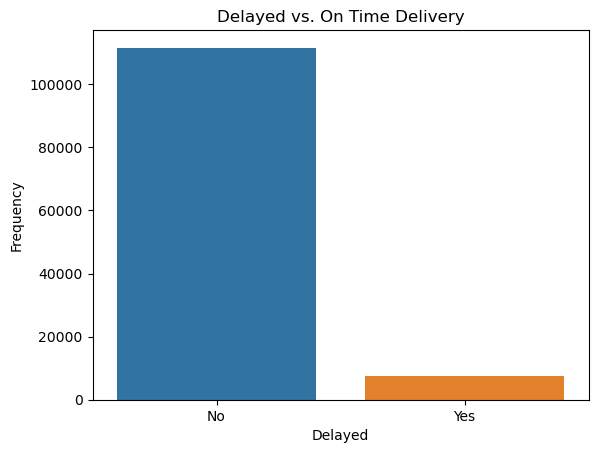

In [76]:
#chart 15
sns.countplot(x=merged_df['delayed'])
plt.title('Delayed vs. On Time Delivery')
plt.xlabel('Delayed')
plt.ylabel('Frequency')

Business Question:
How many orders were delivered late vs on time?

Visualization:
Count Plot showing the distribution of delayed and on-time deliveries.

Key Insight:
Maximum orders were deliverd on time indicating there was no delay which may be due to favorable weather conditions which does not add to delay in delivering orders while shipping and mission of improved services.Reducing the remaining delayed deliveries could further enhance customer satisfaction and operational efficiency.

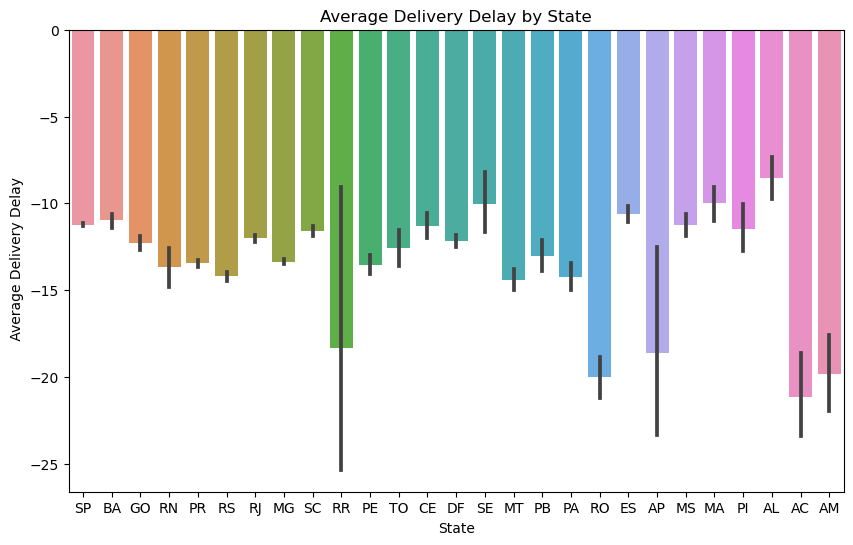

In [77]:
#chart 16
plt.figure(figsize=(10,6))
sns.barplot(x=merged_df['customer_state'],y=merged_df['delivery_delay_days'],estimator='mean')
plt.title('Average Delivery Delay by State')
plt.xlabel('State')
plt.ylabel(' Average Delivery Delay')
plt.show()

Business Question:
How does the average delivery delay vary across different states?

Visualization:
Bar Chart showing the average delivery delay (in days) across different states.

Key Insight:
The chart suggest no state has delayed delivery every state indicating all the orders in every state were delivery before the estimated delivery date.However, the average delivery time varies across states, with some regions delivering orders much earlier than others. This suggests consistent delivery performance across the platform while highlighting opportunities to further optimize logistics in comparatively slower regions.

Text(0, 0.5, 'Frequency')

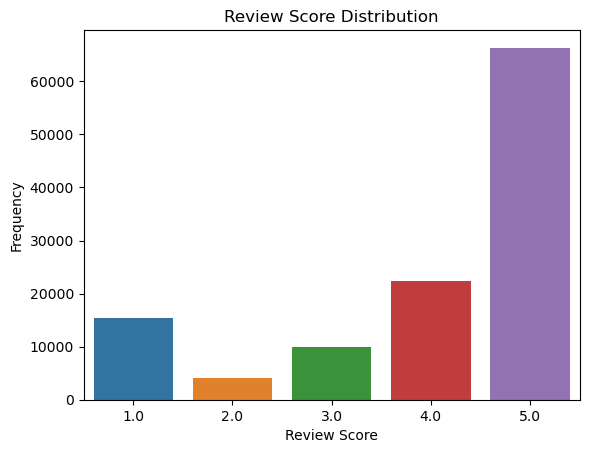

In [78]:
#chart 17
sns.countplot(x=merged_df['review_score'])
plt.title('Review Score Distribution')
plt.xlabel('Review Score')
plt.ylabel('Frequency')

Business Question:
How are customer review scores distributed across all orders?

Visualization:
Count Plot showing the distribution of customer review scores.

Key Insight:
Most customers awarded a 5-star rating, followed by 4-star ratings, indicating a high level of overall customer satisfaction. Low ratings (1 and 2) account for only a small proportion of reviews, suggesting that the majority of customers had a positive shopping experience. Investigating the factors associated with low-rated orders can help improve service quality and enhance the overall customer experience.

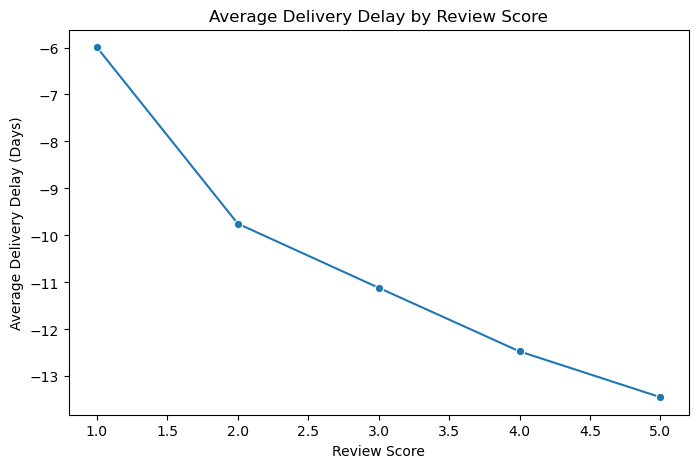

In [79]:
#chart 18
review_delay = (merged_df.groupby('review_score')['delivery_delay_days'].mean())
plt.figure(figsize=(8,5))
sns.lineplot(x=review_delay.index,y=review_delay.values,marker='o')
plt.title('Average Delivery Delay by Review Score')
plt.xlabel('Review Score')
plt.ylabel('Average Delivery Delay (Days)')
plt.show()

Business Question:
How does delivery delay influence customer review ratings?

Visualization:
Bar chart of average deliver delay by review rating.

Key Insight:
The chart suggests 5 star reviewed products are best rated appear to be related to they are delivered the earliest. Orders with higher review scores generally have more negative delivery delays, meaning they are delivered earlier than the estimated delivery date. In contrast, lower-rated orders tend to be delivered closer to the estimated date. This suggests that timely or early deliveries are associated with higher customer satisfaction.

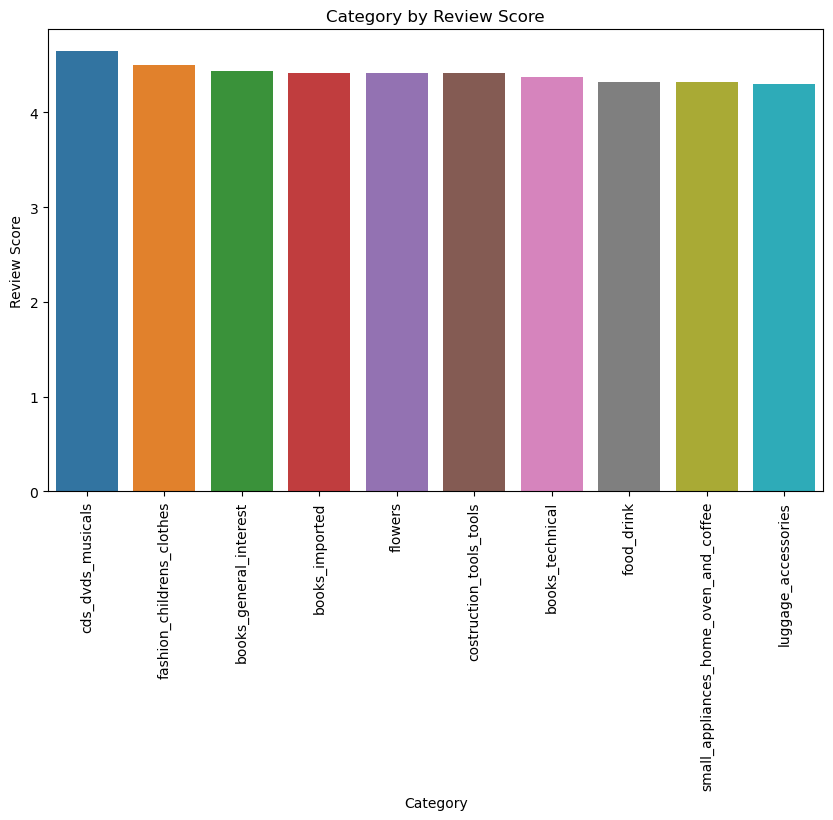

In [80]:
#chart 19
top=merged_df.groupby('product_category_name_english')['review_score'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(y=top.values,x=top.index)
plt.title('Category by Review Score')
plt.ylabel('Review Score')
plt.xticks(rotation=90)
plt.xlabel('Category')
plt.show()

Business Question:
Which product categories receive the highest customer ratings?

Visualization:
Bar Chart showing the average customer review score by product category.

Key Insight:
The cds_dvds_musicals category received the highest average customer rating, followed by fashion_childrens_clothes and books_general_interest. These consistently high ratings indicate strong customer satisfaction within these product categories and may reflect good product quality, reliable delivery, or positive customer experiences. Identifying the factors contributing to these high ratings can help improve customer satisfaction across other categories.Although these categories rank highest, the differences in average review scores are relatively small, indicating that customer satisfaction is consistently high across the top-rated product categories.

Text(0, 0.5, 'Revenue')

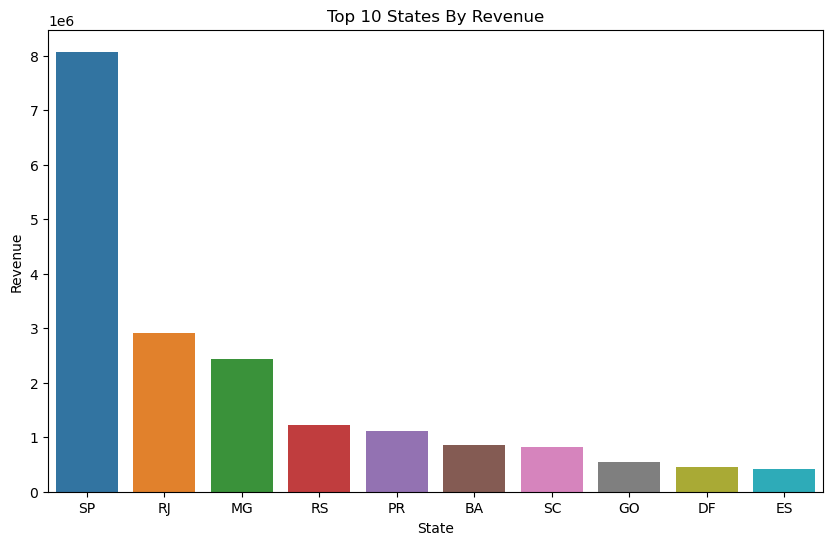

In [81]:
#chart 20
top=merged_df.groupby('customer_state')['total_order_value'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top.index,y=top.values)
plt.title('Top 10 States By Revenue')
plt.xlabel('State')
plt.ylabel('Revenue')

Business Question:
Which state generates the highest revenue?

Visualization:
Bar Chart showing the top 10 states by total revenue generated.

Key Insight:
São Paulo (SP) generates the highest revenue by a substantial margin, followed by Rio de Janeiro (RJ) and Minas Gerais (MG). This highlights SP as the platform's most valuable market in terms of sales. Understanding the factors driving this strong performance can help the business replicate successful strategies in other regions.

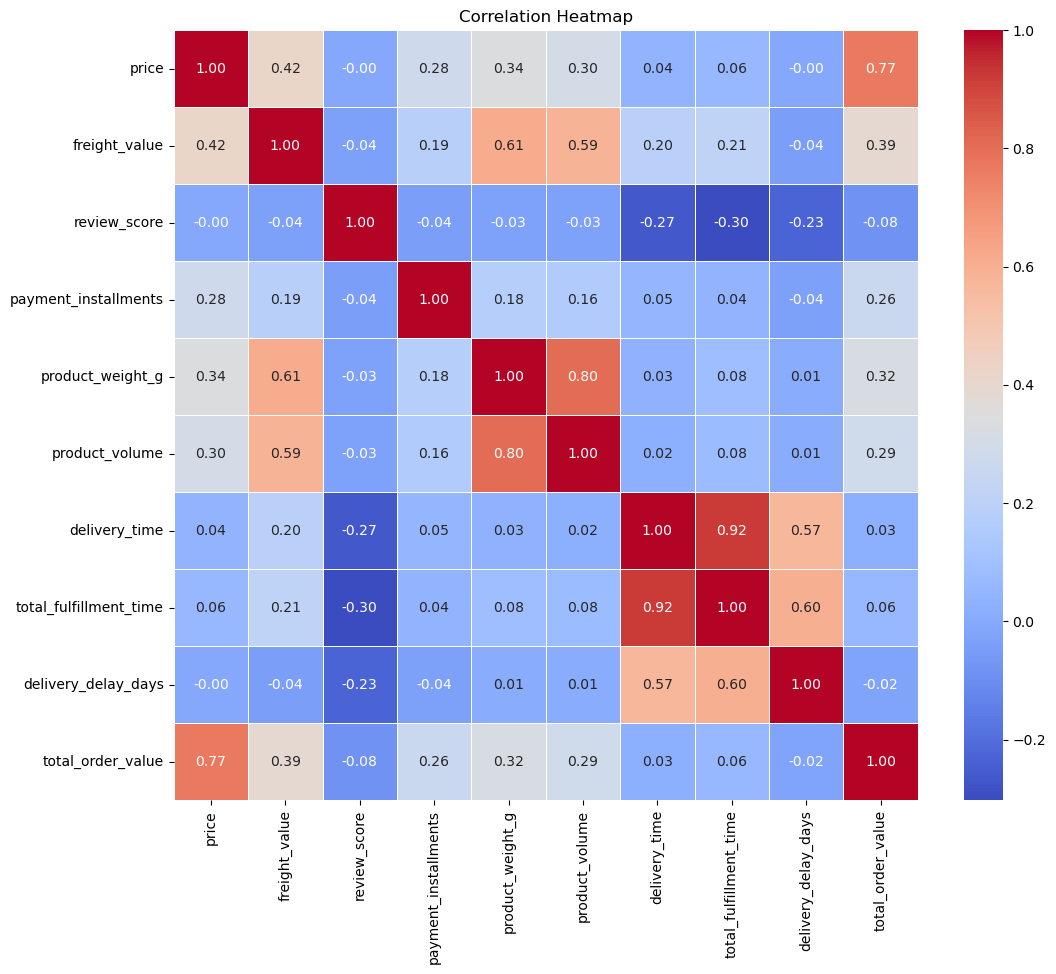

In [82]:
#chart 21
corr_cols = [
    'price',
    'freight_value',
    'review_score',
    'payment_installments',
    'product_weight_g',
    'product_volume',
    'delivery_time',
    'total_fulfillment_time',
    'delivery_delay_days',
    'total_order_value'
]
plt.figure(figsize=(12,10))

sns.heatmap(
    merged_df[corr_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap')
plt.show()

Business Question:
Which numerical features are most strongly related to each other, and what business insights can be derived from these relationships?

Visualization:
Correlation Heatmap showing the relationships among key numerical variables in the dataset.

Key Insight:
The heatmap reveals several important relationships among the numerical variables. Product price has a strong positive correlation with total order value (0.77), indicating that higher-priced products contribute significantly to overall revenue. Product weight and product volume are also highly correlated (0.80), suggesting that larger products generally weigh more and incur higher freight costs. Delivery time and total fulfillment time exhibit a very strong positive correlation (0.92), as longer delivery durations naturally increase the overall fulfillment process. Review scores show a weak negative correlation with delivery-related metrics, indicating that longer deliveries are generally associated with slightly lower customer satisfaction.
#### Strong Positive Correlations
1. Delivery Time ↔ Total Fulfillment Time: 0.92
2. Product Weight ↔ Product Volume: 0.80
3. Price ↔ Total Order Value: 0.77
4. Freight Value ↔ Product Weight: 0.61
5. Freight Value ↔ Product Volume: 0.59
#### Negative Correlations
1. Review Score ↔ Total Fulfillment Time: -0.30
2. Review Score ↔ Delivery Time: -0.27
3. Review Score ↔ Delivery Delay: -0.23

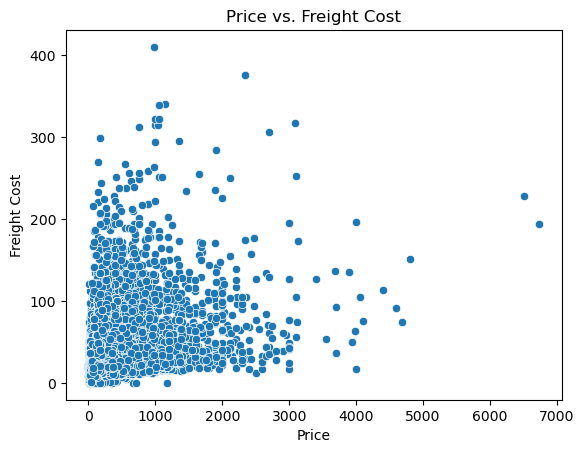

In [83]:
#chart 22
sns.scatterplot(x=merged_df['price'],y=merged_df['freight_value'])
plt.title('Price vs. Freight Cost')
plt.xlabel('Price')
plt.ylabel('Freight Cost')
plt.show()

Business Question:
Is there a relationship between product price and freight cost?

Visualization:
Scatter Plot showing the relationship between product price and freight cost.

Key Insight:
As the price of the products keeping on increasing the freight cost keeps on increasing indicating the increase in price of product suggests that may be the weight of the product is increasing or may be the volume of the product is increasing.

Business Objective
1. São Paulo (SP) is the platform's strongest market.
São Paulo has the highest customer concentration, the largest seller base, and generates the highest revenue among all states. This indicates that SP is the most important market for the business and should remain a primary focus for marketing campaigns, inventory planning, and customer retention initiatives.

2. Sales exhibit clear seasonal trends.
Order volume and sales fluctuate throughout the year, with sales peaking in September and order volume reaching its highest level in August. Understanding these seasonal patterns can help optimize inventory management, staffing, and promotional campaigns during periods of high customer demand.

3. A few product categories contribute significantly to business performance.
Categories such as Bed Bath Table (cama_mesa_banho) and Health & Beauty (beleza_saude) generate the highest revenue, while categories like CDs, DVDs & Music receive the highest customer ratings. These categories represent valuable opportunities for inventory expansion, supplier partnerships, and targeted marketing.

4. Delivery performance is a major strength of the platform.
Most orders are delivered before the estimated delivery date, and only a small proportion experience delays. This indicates an efficient logistics network and contributes positively to the overall customer experience.

5. Faster deliveries are associated with higher customer satisfaction.
Orders delivered earlier tend to receive higher review scores, suggesting a relationship between delivery performance and customer satisfaction. Maintaining reliable delivery timelines can help improve customer loyalty and positive reviews.

6. Customer satisfaction is consistently high.
The majority of customers provide 5-star ratings, while low ratings account for only a small proportion of reviews. This suggests that customers are generally satisfied with the products and services offered by the platform.

7. Credit cards dominate customer payment preferences.
Most customers prefer paying via credit card, and single-installment payments are the most common. These findings can help optimize payment processing strategies and guide the design of financing or promotional offers.

8. Logistics costs are influenced by product characteristics.
Freight cost increases with product volume, product weight, and, to a lesser extent, product price. This indicates that physical product characteristics play an important role in shipping costs and should be considered when planning packaging and logistics strategies.

9. Revenue is concentrated among a limited number of sellers.
A relatively small group of sellers contributes a significant portion of the platform's total revenue. Supporting these high-performing sellers while helping other sellers improve can strengthen the marketplace and increase overall sales.

10. Correlation analysis reveals important operational relationships.
####The strongest positive correlations were observed between:
1. Delivery Time ↔ Total Fulfillment Time
2. Product Weight ↔ Product Volume
3. Price ↔ Total Order Value

Additionally, review scores show a slight negative correlation with delivery-related metrics, indicating that longer deliveries are generally associated with lower customer satisfaction.

Conclusion

This exploratory data analysis of the Brazilian E-Commerce (Olist) dataset transformed multiple relational datasets into a unified analytical view through comprehensive data cleaning, feature engineering, and visualization.

The analysis revealed that São Paulo is the platform's most significant market, contributing the highest customer base, seller concentration, and revenue. Product categories such as Bed Bath Table and Health & Beauty emerged as key revenue drivers, while customer review analysis showed consistently high satisfaction, with most customers awarding 5-star ratings.

Delivery performance proved to be one of the platform's major strengths, with most orders arriving before the estimated delivery date. The analysis also demonstrated that timely deliveries are associated with higher customer review scores, emphasizing the importance of efficient logistics in maintaining customer satisfaction.

Payment behavior indicates a strong customer preference for credit cards and single-installment payments, while logistics analysis showed that freight costs are primarily influenced by product size, weight, and price. Correlation analysis further highlighted meaningful relationships between pricing, fulfillment, shipping costs, and customer satisfaction.

Overall, the findings provide actionable insights that can support decision-making in sales strategy, inventory management, logistics optimization, customer retention, and marketplace expansion. These insights can help the business improve operational efficiency, enhance the customer experience, and drive sustainable revenue growth.

Recommendations
1. Focus marketing and customer acquisition efforts in high-performing states
such as São Paulo, Rio de Janeiro, and Minas Gerais, while exploring growth opportunities in emerging markets.
2. Maintain and further optimize the efficient delivery network, with special attention to the small percentage of delayed orders.
3. Prioritize inventory planning and promotional campaigns for high-revenue product categories such as Bed Bath Table and Health & Beauty.
4. Encourage repeat purchases through loyalty programs, personalized recommendations, and targeted retention campaigns, as the customer base is dominated by one-time buyers.
5. Support high-performing sellers while providing performance insights and operational guidance to lower-performing sellers.
6. Use customer reviews and delivery performance metrics together to identify opportunities for improving the overall shopping experience.
7. Optimize shipping and packaging strategies for larger and heavier products to better manage freight costs.

In [84]:
!pip install psycopg2-binary sqlalchemy

In [86]:
from sqlalchemy import create_engine

# Step 1: Connect to PostgreSQL
# Replace placeholders with your actual details
username = "postgres"      # default user
password = "12345" # the password you set during installation
host = "localhost"         # if running locally
port = "5432"              # default PostgreSQL port
database = "enterprise_e_commerce_analysis"    # the database you created in pgAdmin

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

# Step 2: Load DataFrame into PostgreSQL
table_name = "e_commerce"   # choose any table name
merged_df.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")

Data successfully loaded into table 'e_commerce' in database 'enterprise_e_commerce_analysis'.
